In [28]:
import warnings
warnings.filterwarnings('ignore')
import csv
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.ticker as ticker

# 프로젝트 목표

## 핫플레이스 인구를 표현할 수 있는 데이터를 수집한 후 분석한다.

데이터 수집하기

구글에서 `'서울 시간대별 인구 데이터'`를 검색한다.

<img src="./서울시간대별인구데이터1.png" width="1000" align="left" />

https://data.seoul.go.kr/dataVisual/seoul/seoulLivingPopulation.do

<img src="./서울시간대별인구데이터2.png" width="1000" align="left" />

'서울 열린데이터 광장'이라는 사이트가 나타나면 `'집계구 단위 서울 생활인구 데이터 보기'`를 클릭한다.  
'생활인구'란 실제 거주 인구가 아닌 실제로 생활하는 인구로 통신 기지국을 기반으로 1시간 단위로 추정한 인구 데이터이다.

행정동 단위의 `'서울 생활인구 (내국인)'`을 클릭한다.

<img src="./서울시간대별인구데이터3.png" width="1000" align="left" />

<img src="./서울시간대별인구데이터4.png" width="1000" align="left" />

`LOCAL_PEOPLE_DONG_202607.csv` 파일을 다운로드 받는다. 이전 데이터를 다운로드 받으려면 `전체 파일보기`를 클릭한 후 다운로드 받는다.

LOCAL_PEOPLE_DONG_202607.csv 파일을 열어보면 `행정동코드` 8자리만 나와있고 실제 어느 지역인지를 알 수가 없다. 서울 열린데이터 광장에서는 행정동코드와 코드에 해당하는 행정동명을 별도의 파일로 제공한다.

LOCAL_PEOPLE_DONG_202607.csv 파일을 다운로드 받기위해서 `'서울 생활인구 (내국인)'`을 클릭한 페이지에서 `'전국 행정동 코드정보'`를 클릭해서 다운받는다.

<img src="./서울시간대별인구데이터5.png" width="1000" align="left" />

## 데이터 파일을 읽어온다.

2026년 7월 서울 생활인구 (내국인) 데이터를 읽어온다.

In [2]:
file = open('./data/LOCAL_PEOPLE_DONG_202607.csv', encoding='utf8')
data = csv.reader(file)
data_colunm = next(data) # LOCAL_PEOPLE_DONG_202607.csv 파일의 첫 줄(헤더)을 리턴하고 건너뛴다.
data = list(data)
# print(len(data))
# print(data[0])

2026년 7월 전국 행정동 코드정보 데이터를 읽어온다.

In [3]:
file = open('./data/ADMI_202607.csv', encoding='utf8')
code_data = csv.reader(file)
code_data_colunm = next(code_data) # ADMI_202607.csv 파일의 첫 줄(헤더)을 리턴하고 건너뛴다.
code_data = list(code_data)
# print(len(code_data))
# print(code_data[0])

## 데이터 타입 변환하기

csv 파일을 읽어 들였기 때문에 모든 데이터가 문자열 데이터이므로 처리에 적합한 자료형으로 데이터 타입을 변환한다.

서울 생활인구 (내국인) 데이터

1번째 열 `기준일ID`는 슬라이싱해서 연도, 월, 일을 분리하기 위해서 문자열 상태를 유지한다.  
2번째 열 `시간대구분`과 3번째 열 `행정동코드`는 정수이므로 int() 함수를 사용해서 정수로 데이터 타입을 변환한다.  
4번째 열 `총생활인구수`부터 마지막 열까지는 소수점이 있는 실수이므로 float() 함수를 사용해서 실수로 데이터 타입을 변환한다.

In [4]:
print(len(data[0]))
print(data[0])

33
['20260701', '00', '11545700', '12043.6438', '531.3393', '289.3703', '229.2587', '204.7188', '349.1191', '474.2354', '457.0037', '425.5353', '527.121', '440.6177', '517.3426', '419.3', '309.5805', '591.2483', '390.7971', '211.1994', '298.6279', '293.9756', '374.7541', '380.259', '495.4943', '411.0483', '471.1333', '440.2293', '624.4299', '530.5553', '378.3568', '976.9918', '']


In [5]:
for row in data:
    for i in range(1, 32):
        if i <= 2:
            row[i] = int(row[i]) # 인덱스가 2 이하인 경우 정수로 변환한다.
        else:
            row[i] = float(row[i]) # 인덱스가 2 초과인 경우 실수로 변환한다.
print(data[0])

['20260701', 0, 11545700, 12043.6438, 531.3393, 289.3703, 229.2587, 204.7188, 349.1191, 474.2354, 457.0037, 425.5353, 527.121, 440.6177, 517.3426, 419.3, 309.5805, 591.2483, 390.7971, 211.1994, 298.6279, 293.9756, 374.7541, 380.259, 495.4943, 411.0483, 471.1333, 440.2293, 624.4299, 530.5553, 378.3568, 976.9918, '']


전국 행정동 코드정보 데이터

역시 모든 값이 문자열로 저장되어 있다. 이 중에서 사용할 항목은 세 번째 열의 `ADMI_NM(행정동명)`과 네 번째 열의 `ADMI_CD(행정동코드)`이다. 행정동명은 문자열 그대로 사용하면 되므로 행정동코드만 정수이므로 int() 함수를 사용해서 정수로 데이터 타입을 변환한다.

In [6]:
print(code_data[0])

['서울특별시', '종로구', '청운효자동', '11110515', '서울특별시 종로구 청운효자동', '202607']


In [7]:
for row in code_data:
    row[3] = int(row[3])
print(code_data[0])

['서울특별시', '종로구', '청운효자동', 11110515, '서울특별시 종로구 청운효자동', '202607']


행정동이름과 행정동코드를 연결하기

분석할 행정동이름을 입력받아서 행정동이름에 해당되는 행정동코드를 얻어낸다.

In [8]:
dong_code = 0
while dong_code == 0:
    dong_name = input('핫플레이스가 위치한 행정동이름을 입력하세요: ')
    for row in code_data:
        if row[2] == dong_name:
            dong_code = row[3]
            break
        # ===== if
    # ===== for
    if dong_code == 0:
        print(f'{dong_name}은 잘못된 행정동이름 입니다람쥐....')
    # ===== if
# ===== while
print(f'{dong_name}({dong_code})를(을) 분석합니다.')

핫플레이스가 위치한 행정동이름을 입력하세요: 망원1동
망원1동(11440690)를(을) 분석합니다.


## 시간대별 생활인구 분석하기

시간대별 평균 생활인구를 저장할 0으로 초기화된 길이가 24인 리스트를 만든다.

In [9]:
# pop = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# pop = []
# for i in range(24):
    # pop.append(0)
# pop = [0] * 24
pop = [0 for i in range(24)]
print(len(pop), pop)

24 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


`시간대구분`은 열 인덱스 `[1]`, `총생활인구수`는 열 인덱스 `[3]`이므로 `시간대구분`을 리스트의 인덱스로 사용해서 날짜별 `총생활인구수`의 평균을 시간대별로 저장한다.

In [10]:
for row in data:
    if row[2] == dong_code: # 입력한 행정동이름에 해당되는 행정동코드 인가?
        pop[row[1]] += row[3] # 시간대구분별(row[1]) 총생활인구수(row[3])의 합계를 계산한다.
# 시간대구분별 총생활인구수의 일별 평균을 계산한다.
# round(): 반올림, math.floor(): 내림, math.ceil(): 올림
pop = [round(p / 31) for p in pop]
print(pop)

[21460, 21607, 21515, 21495, 21497, 21136, 20700, 19567, 17744, 17113, 16991, 17123, 17343, 17428, 17730, 18129, 18536, 19018, 19877, 20410, 20429, 20491, 20774, 21697]


핫플레이스가 위치한 행정동의 시간대별 평균 생활인구수 시각화

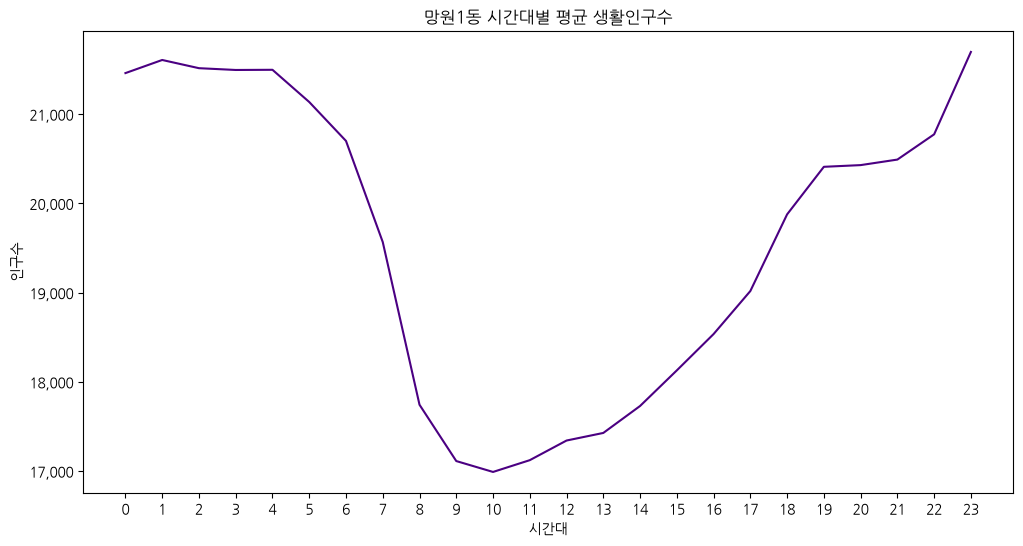

In [11]:
plt.figure(figsize=(12, 6))
plt.title(dong_name + ' 시간대별 평균 생활인구수')
plt.plot(range(24), pop, color='indigo')
plt.xlabel('시간대')
plt.ylabel('인구수')
plt.xticks(range(24))
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

## 주중/주말 시간대별 생활인구 분석하기

In [12]:
import datetime as dt

In [13]:
pop_weekday = [0 for i in range(24)] # 주중 시간대별 평균 생활인구수를 기억할 리스트
pop_weekend = [0 for i in range(24)] # 주말 시간대별 평균 생활인구수를 기억할 리스트
# print(pop_weekday, pop_weekend)

for row in data:
    if row[2] == dong_code:
        # 날짜 데이터(row[0])를 슬라이싱을 이용해서 년, 월, 일로 분리한다.
        year, month, day = int(row[0][:4]), int(row[0][4:6]), int(row[0][6:])
        # 요일을 계산한다.
        week = dt.date(year, month, day).weekday()
        # 주중 - 일(6), 월(0), 화(1), 수(2), 목(3), 주말 - 금(4), 토(5), 생활인구 합계를 계산한다.
        if week in [0, 1, 2, 3, 6]:
            pop_weekday[row[1]] += row[3] # 주중 생활인구 합계를 계산한다.
        else:
            pop_weekend[row[1]] += row[3] # 주말 생활인구 합계를 계산한다.
        # ===== if
    # ===== if
# ===== for

# 2026년 7월의 주중, 주말 날자수를 계산한다.
cnt_weekday, cnt_weekend = 0, 0
for i in range(1, 32):
    if dt.date(2026, 7, i).weekday() in [0, 1, 2, 3, 6]:
        cnt_weekday += 1
    else:
        cnt_weekend += 1
# print(cnt_weekday, cnt_weekend)

# 주중, 주말 생활인구의 평균을 계산한다.
pop_weekday = [round(p / cnt_weekday) for p in pop_weekday]
pop_weekend = [round(p / cnt_weekend) for p in pop_weekend]
print(f'주중 생활인구수 평균: {pop_weekday}')
print(f'주말 생활인구수 평균: {pop_weekend}')

주중 생활인구수 평균: [21511, 21589, 21491, 21465, 21466, 21111, 20688, 19416, 17325, 16634, 16478, 16548, 16762, 16801, 17121, 17515, 17931, 18436, 19402, 19994, 20085, 20213, 20532, 21504]
주말 생활인구수 평균: [21336, 21651, 21574, 21567, 21572, 21197, 20729, 19936, 18769, 18281, 18244, 18528, 18764, 18963, 19217, 19628, 20016, 20441, 21037, 21425, 21268, 21173, 21366, 22168]


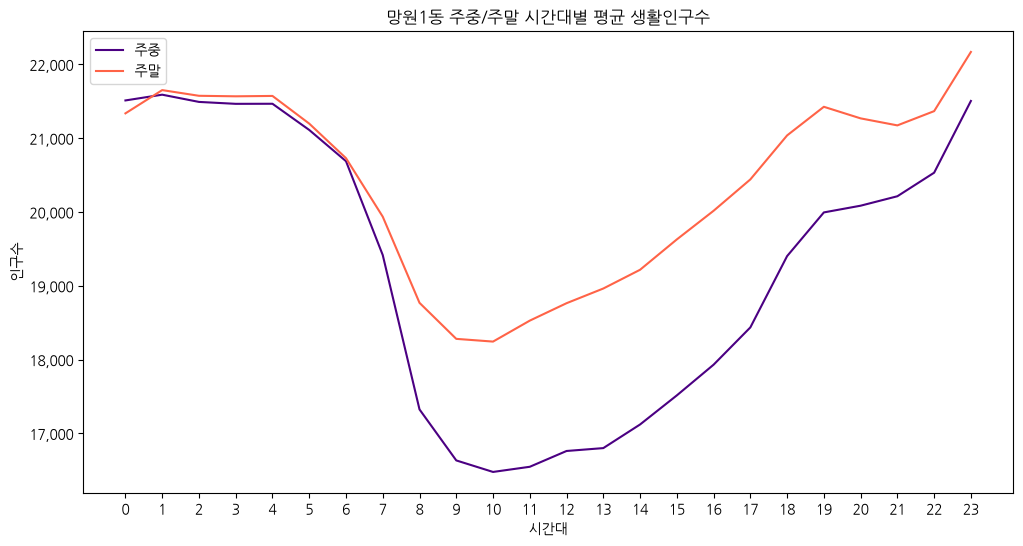

In [14]:
plt.figure(figsize=(12, 6))
plt.title(dong_name + ' 주중/주말 시간대별 평균 생활인구수')
plt.plot(range(24), pop_weekday, color='indigo', label='주중')
plt.plot(range(24), pop_weekend, color='tomato', label='주말')
plt.xlabel('시간대')
plt.ylabel('인구수')
plt.xticks(range(24))
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.show()

## 남녀 시간대별 생활인구 분석하기

In [15]:
# print(data_colunm)
print(data_colunm[4:18])
print(data_colunm[18:32])
# print(code_data_colunm)

['남자0세부터9세생활인구수', '남자10세부터14세생활인구수', '남자15세부터19세생활인구수', '남자20세부터24세생활인구수', '남자25세부터29세생활인구수', '남자30세부터34세생활인구수', '남자35세부터39세생활인구수', '남자40세부터44세생활인구수', '남자45세부터49세생활인구수', '남자50세부터54세생활인구수', '남자55세부터59세생활인구수', '남자60세부터64세생활인구수', '남자65세부터69세생활인구수', '남자70세이상생활인구수']
['여자0세부터9세생활인구수', '여자10세부터14세생활인구수', '여자15세부터19세생활인구수', '여자20세부터24세생활인구수', '여자25세부터29세생활인구수', '여자30세부터34세생활인구수', '여자35세부터39세생활인구수', '여자40세부터44세생활인구수', '여자45세부터49세생활인구수', '여자50세부터54세생활인구수', '여자55세부터59세생활인구수', '여자60세부터64세생활인구수', '여자65세부터69세생활인구수', '여자70세이상생활인구수']


In [16]:
male = [0 for i in range(24)] # 남자 시간대별 평균 생활인구수를 기억할 리스트
female = [0 for i in range(24)] # 여자 시간대별 평균 생활인구수를 기억할 리스트
# print(male, female)

for row in data:
    if row[2] == dong_code:
        male[row[1]] += sum(row[4:18]) # 남자 생활인구 합계를 계산한다.
        female[row[1]] += sum(row[18:32]) # 여자 생활인구 합계를 계산한다.
# print(male, female)

# 남자, 여자 생활인구의 평균을 계산한다.
male = [round(p / 31) for p in male]
female = [round(p / 31) for p in female]
print(f'남자 생활인구수 평균: {male}')
print(f'여자 생활인구수 평균: {female}')

남자 생활인구수 평균: [9748, 9782, 9730, 9712, 9746, 9612, 9414, 8822, 8046, 7748, 7645, 7683, 7680, 7651, 7676, 7820, 8006, 8286, 8675, 8986, 9068, 9195, 9388, 9864]
여자 생활인구수 평균: [11712, 11825, 11785, 11782, 11751, 11524, 11286, 10746, 9698, 9365, 9346, 9441, 9663, 9777, 10054, 10309, 10530, 10732, 11202, 11423, 11361, 11296, 11386, 11833]


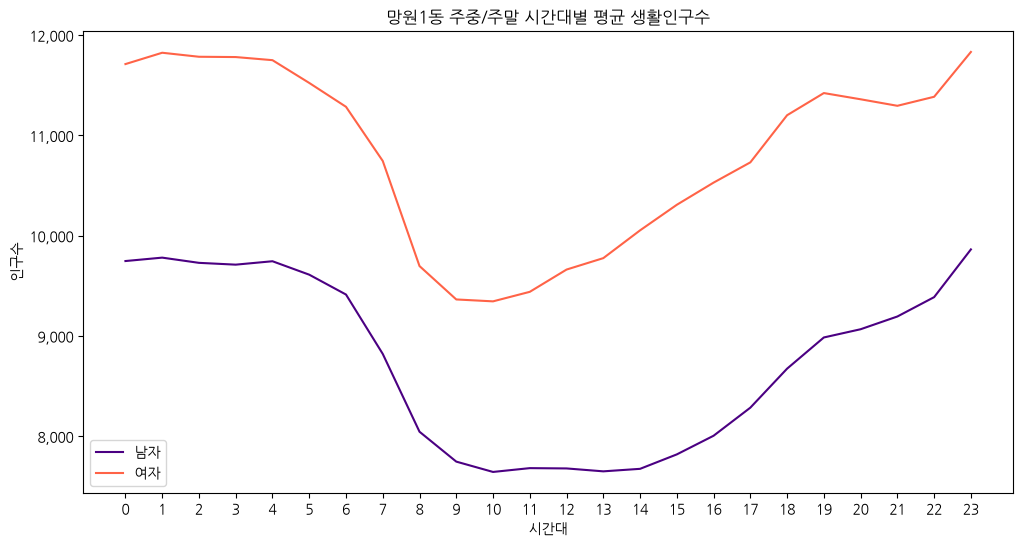

In [17]:
plt.figure(figsize=(12, 6))
plt.title(dong_name + ' 주중/주말 시간대별 평균 생활인구수')
plt.plot(range(24), male, color='indigo', label='남자')
plt.plot(range(24), female, color='tomato', label='여자')
plt.xlabel('시간대')
plt.ylabel('인구수')
plt.xticks(range(24))
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.show()

## 서로 다른 지역간의 생활인구 분석하기

In [18]:
dong_code1 = 0
while dong_code1 == 0:
    dong_name1 = input('핫플레이스가 위치한 행정동이름을 입력하세요: ')
    for row in code_data:
        if row[2] == dong_name1:
            dong_code1 = row[3]
            break
    if dong_code1 == 0:
        print(f'{dong_name1}은 잘못된 핫플레이스 행정동이름 입니다람쥐....')

dong_code2 = 0
while dong_code2 == 0:
    dong_name2 = input('비교할 행정동이름을 입력하세요: ')
    for row in code_data:
        if row[2] == dong_name2:
            dong_code2 = row[3]
            break
    if dong_code2 == 0:
        print(f'{dong_name2}은 잘못된 비교할 행정동이름 입니다람쥐....')

print(f'{dong_name1}({dong_code1})과 {dong_name2}({dong_code2})를(을) 분석합니다.')

핫플레이스가 위치한 행정동이름을 입력하세요: 압구정동
비교할 행정동이름을 입력하세요: 역삼1동
압구정동(11680545)과 역삼1동(11680640)를(을) 분석합니다.


In [19]:
pop1 = [0 for i in range(24)] # 핫플레이스 시간대별 평균 생활인구수를 기억할 리스트
pop2 = [0 for i in range(24)] # 안 핫플레이스 시간대별 평균 생활인구수를 기억할 리스트
# print(pop1, pop1)

for row in data:
    # 핫플레이스가 있는 행정동인 경우
    if row[2] == dong_code1:
        pop1[row[1]] += row[3]
    # 안 핫플레이스가 있는 행정동인 경우
    elif row[2] == dong_code2:
        pop2[row[1]] += row[3]
# print(male, female)

# 핫플레이스, 안 핫플레이스 생활인구의 평균을 계산한다.
pop1 = [round(p / 31) for p in pop1]
pop2 = [round(p / 31) for p in pop2]
print(f'핫플레이스 생활인구수 평균: {pop1}')
print(f'안 핫플레이스 생활인구수 평균: {pop2}')

핫플레이스 생활인구수 평균: [30360, 29341, 28548, 27890, 28115, 28673, 30050, 32826, 39505, 46483, 51211, 54470, 56665, 58086, 58192, 57852, 56594, 55265, 51410, 46578, 42431, 38916, 34979, 31743]
안 핫플레이스 생활인구수 평균: [63203, 61710, 60920, 60249, 59854, 60445, 64031, 75084, 97235, 121248, 133342, 143374, 148031, 149675, 149735, 147534, 143065, 135097, 120593, 106964, 96548, 85986, 75031, 66281]


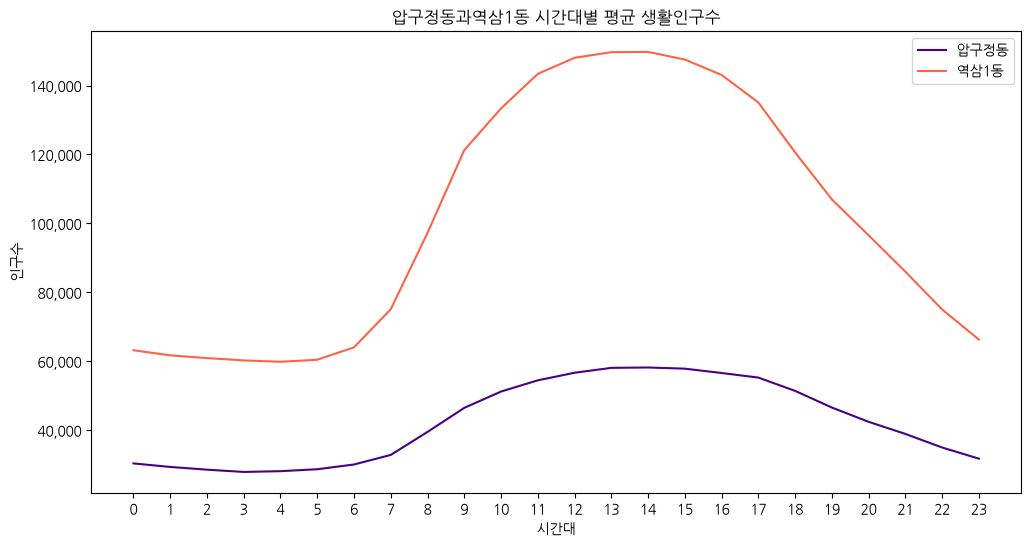

In [20]:
plt.figure(figsize=(12, 6))
plt.title(dong_name1 + '과' + dong_name2 + ' 시간대별 평균 생활인구수')
plt.plot(range(24), pop1, color='indigo', label=dong_name1)
plt.plot(range(24), pop2, color='tomato', label=dong_name2)
plt.xlabel('시간대')
plt.ylabel('인구수')
plt.xticks(range(24))
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.show()

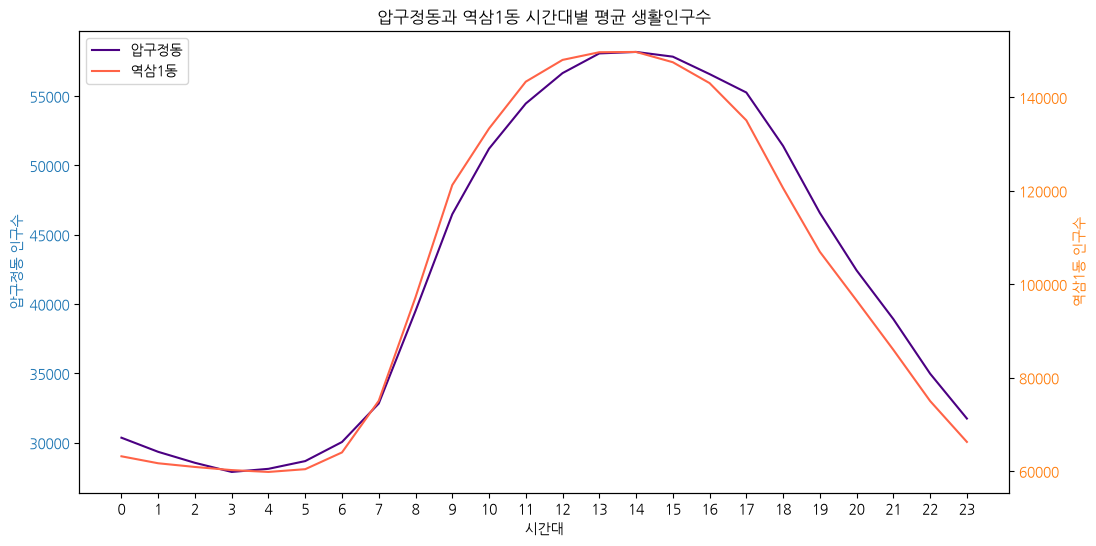

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 첫 번째 y축(왼쪽) 설정
color = 'tab:blue'
ax1.set_xlabel('시간대')
ax1.set_ylabel(dong_name1 + ' 인구수', color=color)
line1 = ax1.plot(range(24), pop1, color='indigo', label=dong_name1)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(24))

# 보조 y축(오른쪽) 생성 
ax2 = ax1.twinx() # ax1과 x축을 공유하는 새로운 축 객체 생성
color = 'tab:orange'
ax2.set_ylabel(dong_name2 + ' 인구수', color=color)
line2 = ax2.plot(range(24), pop2, color='tomato', label=dong_name2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(dong_name1 + '과 ' + dong_name2 + ' 시간대별 평균 생활인구수')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.show()